In [4]:
## This notebook will analyze the csv files that has ben scrapped for F1 drivers.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
reddit_df = pd.read_csv("Reddit_Posts_1.csv")
#Let's describe the dataframe so we can see the high level statistics.
reddit_df

,User,Date,Title,Number_Votes,Number_Comments
0,formula1,2025-10-26,When and in which car the current drivers ...,187 votes,43 comments
1,formula1,2025-04-23,F1 butchered its 2026 cars for an ideal it...,3.8K votes,508 comments
2,formula1,2025-09-18,What’s a piece of Formula 1 lost media tha...,1.6K votes,307 comments
3,formuladank,2025-11-04,formula 1: the pinnacle of horrors,4.4K votes,72 comments
4,formula1,2025-08-13,"In your opinion, which Formula 1 season ha...",3.3K votes,628 comments
...,...,...,...,...,...
115,lewishamilton,2021-12-14,Formula One Is No Longer A Sport,36 votes,22 comments
116,formula1,2025-06-25,To those who have seen it what are your op...,664 votes,224 comments
117,formula1,2024-02-26,"Going into the 75th season, what is your f...",10K votes,589 comments
118,UmaMusume,2025-10-10,You may have seen Umamusume with F1 graphi...,158 votes,12 comments


In [7]:
reddit_df1 = pd.read_csv("Reddit_Posts.csv")
reddit_df1

,User,Date,Title,Number_Votes,Number_Comments
0,formula1,2025-10-19,[F1statsguru] Lewis Hamilton takes an unwa...,4.8K votes,555 comments
1,formuladank,2025-11-04,formula 1: the pinnacle of horrors,4.4K votes,72 comments
2,formula1,2025-09-18,What’s a piece of Formula 1 lost media tha...,1.6K votes,307 comments
3,formula1,2025-11-09,Max Verstappen has just become the driver ...,27K votes,572 comments
4,nextfuckinglevel,2025-10-13,The Insane Speed of Formula 1 Cars,462 votes,63 comments
...,...,...,...,...,...
180,apple,2025-07-09,Apple Now Wants to Buy Streaming Rights fo...,2.1K votes,269 comments
181,Watches,2025-10-03,[Tag Heuer] Honest thoughts on the Formula...,76 votes,55 comments
182,australia,2025-03-12,Japanese Formula 1 driver Yuki Tsunoda pro...,8.4K votes,165 comments
183,formula1,2024-05-26,[Autosport] When the family finishes 1-2 i...,2K votes,34 comments


In [8]:
drivers_x = pd.read_csv("Drivers_x.csv")
drivers_x.sort_values(by='followers', ascending=False, inplace=True)
drivers_x

,User,Favourite,followers
33,Lewis Hamilton,2595,8534028
11,Max Verstappen,1458,4092692
6,Sergio Pérez,884,3917499
0,Fernando Alonso,1389,3755533
16,Charles Leclerc,32348,3628423
7,Daniel Ricciardo,587,3400942
12,Carlos Sainz,1619,2924279
17,Lando Norris,14565,2897398
18,George Russell,6361,2502925
8,Valtteri Bottas,9583,1940317


In [9]:
constructors_x = pd.read_csv("Constructors_x.csv")
constructors_x.drop_duplicates(inplace=True)
constructors_x

,User,Favourite,followers
0,BWT Alpine Formula One Team,24544,2325423
2,Alfa Romeo F1 Team,1868,4902
3,Mercedes-AMG PETRONAS F1 Team,121334,5240210
4,MoneyGram Haas F1 Team,5397,1823500
5,BWT Alpine Formula One Team,24544,2325417
6,McLaren,20596,4509067
8,Scuderia Ferrari HP,6721,5737560
9,Stake F1 Team KICK Sauber,10498,1604602
10,Visa Cash App Racing Bulls F1 Team,8948,1780012


In [10]:
import pandas as pd
import re

def extract_number(x):
    if not isinstance(x,str):
        return pd.NA

    m = re.search(r'\d+', x.replace(',', ''))
    if m:
        return int(m.group(0))
    else:
        return pd.NA


def clean_reddit(df):
    # convert date
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # clean "187 votes" → 187
    df['Number_Votes'] = df['Number_Votes'].apply(extract_number)
    df['Number_Comments'] = df['Number_Comments'].apply(extract_number)

    # Lowercase text for later sentiment / NLP
    df['Title'] = df['Title'].str.lower()

    return df

reddit1 = clean_reddit(reddit_df)
reddit2 = clean_reddit(reddit_df1)

# Combine them
reddit = pd.concat([reddit1, reddit2], ignore_index=True)


In [11]:
reddit_daily = reddit.groupby('Date').agg({'Title':'count', 'Number_Votes':'sum', 'Number_Comments': 'sum'}).reset_index()

In [12]:
reddit_daily.rename(columns={'Title':'Reddit_Posts'}, inplace=True)

In [13]:
reddit_daily

,Date,Reddit_Posts,Number_Votes,Number_Comments
0,2016-12-02,1,3,1
1,2018-11-10,1,13,271
2,2019-07-25,1,235,11
3,2020-03-18,1,10,2
4,2020-05-14,1,200,36
...,...,...,...,...
187,2025-11-04,2,8,144
188,2025-11-05,2,461,90
189,2025-11-06,1,1,61
190,2025-11-09,3,175,1193


In [14]:
#Read race results into a DataFrame
race_results = pd.read_csv("f1_race_results_2020_2024.csv")
race_results

,race ID,year,round,name,driver ID,constructor ID,position,position.1,driver race points,status ID,constructor race points
0,1031,2020,1,Austrian Grand Prix,822,131,1,1,25.0,1,37.0
1,1031,2020,1,Austrian Grand Prix,844,6,2,2,18.0,1,19.0
2,1031,2020,1,Austrian Grand Prix,846,1,3,3,16.0,1,26.0
3,1031,2020,1,Austrian Grand Prix,1,131,4,4,12.0,1,37.0
4,1031,2020,1,Austrian Grand Prix,832,1,5,5,10.0,1,26.0
...,...,...,...,...,...,...,...,...,...,...,...
2134,1144,2024,24,Abu Dhabi Grand Prix,825,210,16,16,0.0,11,4.0
2135,1144,2024,24,Abu Dhabi Grand Prix,859,215,17,17,0.0,5,0.0
2136,1144,2024,24,Abu Dhabi Grand Prix,822,15,\N,18,0.0,130,0.0
2137,1144,2024,24,Abu Dhabi Grand Prix,861,3,\N,19,0.0,5,0.0


In [15]:
#read cosntructors csv into dataframe
constructors = pd.read_csv("f1_constructors_lookup_2020_2024.csv")
constructors

,constructor ID,name
0,1,McLaren
1,3,Williams
2,4,Renault
3,6,Ferrari
4,9,Red Bull
5,15,Sauber
6,51,Alfa Romeo
7,117,Aston Martin
8,131,Mercedes
9,210,Haas F1 Team


In [16]:
# Read drivers into a DataFrame
f1_drivers = pd.read_csv("f1_drivers_lookup_2020_2024.csv")
f1_drivers

,driver ID,name
0,1,Lewis Hamilton
1,4,Fernando Alonso
2,8,Kimi Räikkönen
3,9,Robert Kubica
4,20,Sebastian Vettel
5,154,Romain Grosjean
6,842,Pierre Gasly
7,807,Nico Hülkenberg
8,815,Sergio Pérez
9,817,Daniel Ricciardo


In [69]:
driver_race_merge = f1_drivers.merge(race_results, on='driver ID')
driver_race_merge

,driver ID,name_x,race ID,year,round,name_y,constructor ID,position,position.1,driver race points,status ID,constructor race points
0,1,Lewis Hamilton,1031,2020,1,Austrian Grand Prix,131,4,4,12.0,1,37.0
1,1,Lewis Hamilton,1032,2020,2,Styrian Grand Prix,131,1,1,25.0,1,43.0
2,1,Lewis Hamilton,1033,2020,3,Hungarian Grand Prix,131,1,1,26.0,1,41.0
3,1,Lewis Hamilton,1034,2020,4,British Grand Prix,131,1,1,25.0,1,25.0
4,1,Lewis Hamilton,1035,2020,5,70th Anniversary Grand Prix,131,2,2,19.0,1,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2134,861,Franco Colapinto,1141,2024,21,São Paulo Grand Prix,3,\N,17,0.0,3,0.0
2135,861,Franco Colapinto,1142,2024,22,Las Vegas Grand Prix,3,14,14,0.0,1,0.0
2136,861,Franco Colapinto,1143,2024,23,Qatar Grand Prix,3,\N,19,0.0,4,0.0
2137,861,Franco Colapinto,1144,2024,24,Abu Dhabi Grand Prix,3,\N,19,0.0,5,0.0


In [70]:
# Driver total points has been shown in this DataFrame between 2020-2024 to show which drivers had the most point during this time frame
# This is important becuase we can try to analyze the fan engamement with specific racer to find how successfull they become
driver_points = driver_race_merge.groupby('name_x')[['driver race points']].sum().sort_values(by='driver race points', ascending=False)
driver_points.reset_index(inplace=True)
driver_points.rename(columns={'name_x':'Driver'},inplace=True)
driver_points

,Driver,driver race points
0,Max Verstappen,1964.5
1,Lewis Hamilton,1389.5
2,Charles Leclerc,1060.0
3,Sergio Pérez,1004.0
4,Carlos Sainz,936.5
5,Lando Norris,901.0
6,George Russell,664.0
7,Valtteri Bottas,499.0
8,Fernando Alonso,430.0
9,Oscar Piastri,347.0


In [71]:
constructor_points = race_results.merge(constructors, on='constructor ID')
constructor_points

,race ID,year,round,name_x,driver ID,constructor ID,position,position.1,driver race points,status ID,constructor race points,name_y
0,1031,2020,1,Austrian Grand Prix,822,131,1,1,25.0,1,37.0,Mercedes
1,1031,2020,1,Austrian Grand Prix,844,6,2,2,18.0,1,19.0,Ferrari
2,1031,2020,1,Austrian Grand Prix,846,1,3,3,16.0,1,26.0,McLaren
3,1031,2020,1,Austrian Grand Prix,1,131,4,4,12.0,1,37.0,Mercedes
4,1031,2020,1,Austrian Grand Prix,832,1,5,5,10.0,1,26.0,McLaren
...,...,...,...,...,...,...,...,...,...,...,...,...
2134,1144,2024,24,Abu Dhabi Grand Prix,825,210,16,16,0.0,11,4.0,Haas F1 Team
2135,1144,2024,24,Abu Dhabi Grand Prix,859,215,17,17,0.0,5,0.0,RB F1 Team
2136,1144,2024,24,Abu Dhabi Grand Prix,822,15,\N,18,0.0,130,0.0,Sauber
2137,1144,2024,24,Abu Dhabi Grand Prix,861,3,\N,19,0.0,5,0.0,Williams


In [72]:
constructor_points.groupby('name_y')[['constructor race points']].sum().sort_values(by='constructor race points', ascending=False)

,constructor race points
name_y,
Red Bull,6225.0
Mercedes,5157.0
Ferrari,4133.0
McLaren,3208.0
Alpine F1 Team,1026.0
Aston Martin,1012.0
AlphaTauri,618.0
Racing Point,420.0
Renault,362.0


<Axes: >

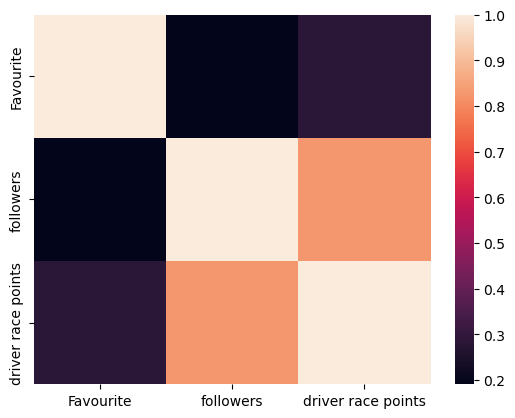

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
# Using heatmap to analyze X data and correlation betweene ach feature!
sns.heatmap(driver_social_media_x_merged.drop(columns='Driver').corr())

In [73]:
#We will connect racer points with their X profile information so we can check and see if popularity has correlation between followers and driver race points!
drivers_x.rename(columns={'User':'Driver'}, inplace=True)
driver_social_media_x_merged = drivers_x.merge(driver_points, on='Driver')
driver_social_media_x_merged.sort_values(by='followers', ascending=False)

,Driver,Favourite,followers,driver race points
0,Lewis Hamilton,2595,8534028,1389.5
1,Max Verstappen,1458,4092692,1964.5
2,Sergio Pérez,884,3917499,1004.0
3,Fernando Alonso,1389,3755533,430.0
4,Charles Leclerc,32348,3628423,1060.0
5,Daniel Ricciardo,587,3400942,280.0
6,Carlos Sainz,1619,2924279,936.5
7,Lando Norris,14565,2897398,901.0
8,George Russell,6361,2502925,664.0
9,Valtteri Bottas,9583,1940317,499.0


In [102]:
reddit_f1 = pd.read_csv("f1_reddit_posts.csv")
reddit_f1

,driver,title,text,score,upvote ratio,upvotes,downvotes,number of comments,url,created_utc
0,Max Verstappen,Max Verstappen wins the 2021 Abu Dhabi Grand Prix,NaN,67182,0.81,67182,0,12124,https://i.redd.it/s8exh758h4581.png,1.639320e+09
1,Max Verstappen,Max Verstappen wins the 70th Anniversary Grand...,NaN,43954,0.92,43954,0,2127,https://i.redd.it/guluamk2mzf51.png,1.596984e+09
2,Max Verstappen,Max Verstappen has now more sprint race victor...,NaN,41634,0.89,41634,0,705,https://i.redd.it/6j33flnlrsb71.jpg,1.626538e+09
3,Max Verstappen,Max Verstappen wins the 2022 Saudi Arabian Gra...,NaN,41280,0.82,41280,0,3017,https://i.redd.it/aonvoauzyyp81.png,1.648406e+09
4,Max Verstappen,Max Verstappen wins the 2021 Formula One World...,NaN,40959,0.78,40959,0,5632,https://i.redd.it/jiysupqnh4581.jpg,1.639320e+09
...,...,...,...,...,...,...,...,...,...,...
415,Nico Hulkenberg,F1 Driver Logos 2025,Lawson's seems similar to Landos and Doohans v...,9278,0.96,9278,0,822,https://i.redd.it/aivnzok1j8be1.png,1.736109e+09
416,Nico Hulkenberg,[Countdown]-2. The number of balls offered by ...,NaN,8614,0.95,8614,0,218,https://i.redd.it/mi37h3cskrl21.jpg,1.552430e+09
417,Nico Hulkenberg,"It's been an interesting season so far , isn't...",NaN,8359,0.99,8359,0,282,https://i.redd.it/32j2x2w0z8ld1.png,1.724782e+09
418,Nico Hulkenberg,F1 Breaking News Updated,NaN,7713,0.99,7713,0,208,https://i.redd.it/2dr911lukerd1.jpeg,1.727465e+09


In [75]:
reddit = pd.read_csv('f1_reddit_posts.csv')

# convert created_utc from unix to datetime
reddit['created_utc'] = pd.to_datetime(reddit['created_utc'], unit='s')

# rename for clarity
reddit = reddit.rename(columns={
    'created_utc': 'date',
    'score': 'engagement_score',
    'number of comments': 'num_comments'
})

# lowercase title for NLP
reddit['title'] = reddit['title'].astype(str).str.lower()

reddit.head()
reddit.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   driver            420 non-null    object        
 1   title             420 non-null    object        
 2   text              57 non-null     object        
 3   engagement_score  420 non-null    int64         
 4   upvote ratio      420 non-null    float64       
 5   upvotes           420 non-null    int64         
 6   downvotes         420 non-null    int64         
 7   num_comments      420 non-null    int64         
 8   url               420 non-null    object        
 9   date              420 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 32.9+ KB


In [76]:
reddit['engagement'] = reddit['engagement_score'] + reddit['num_comments']
reddit[['engagement_score', 'num_comments', 'engagement']].describe()


,engagement_score,num_comments,engagement
count,420.000000,420.000000,420.000000
mean,18568.759524,913.302381,19482.061905
std,12134.401933,1089.203073,12840.893218
min,3594.000000,63.000000,3859.000000
25%,9594.500000,303.500000,10107.000000
50%,16085.500000,536.000000,16851.500000
75%,23804.250000,1075.000000,25108.000000
max,74955.000000,12124.000000,79306.000000


In [97]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def sentiment(text):
    return analyzer.polarity_scores(text)['compound']

reddit['sentiment'] = reddit['title'].apply(sentiment)
reddit[['title','sentiment']].sort_values('title').head(5)


,title,sentiment
156,"10 years ago today, sebastian vettel becomes t...",0.5994
173,2025 japanese grand prix - free practice 1 cla...,0.7430
212,2025 japanese grand prix - free practice 1 cla...,0.7430
237,5 years ago lance stroll's car is flipped upsi...,0.7717
43,[@charles_leclerc] charles leclerc on instagram,0.0000


In [86]:
#reddit.rename(columns={'driver':'Driver'}, inplace=True)
#reddit = reddit.merge(driver_social_media_x_merged, on='Driver')
reddit
reddit[['Driver', 'engagement_score', 'sentiment', 'driver race points']].groupby('Driver').agg('mean').sort_values('engagement_score', ascending=False)
#reddit['Driver'].unique()
#reddit_f1['driver'].unique()

,engagement_score,sentiment,driver race points
Driver,,,
Lewis Hamilton,39148.25,0.297195,1389.5
Max Verstappen,36586.20,0.531990,1964.5
Lando Norris,27099.35,0.251760,901.0
Charles Leclerc,26742.35,0.396145,1060.0
Carlos Sainz,24916.95,0.270030,936.5
Oscar Piastri,22260.40,0.321035,347.0
George Russell,19924.55,0.204915,664.0
Lance Stroll,17014.30,0.278630,219.0
Fernando Alonso,16987.30,0.179120,430.0


In [96]:
corr = reddit['sentiment'].corr(reddit['driver race points'])
corr

0.2277392839929271

In [26]:
sent_by_driver = (
    reddit.groupby('driver')['sentiment']
    .mean()
    .sort_values(ascending=False)
)

sent_by_driver


driver
Max Verstappen       0.531990
Charles Leclerc      0.396145
Sergio Perez         0.367595
Gabriel Bortoleto    0.335700
Oscar Piastri        0.321035
Lewis Hamilton       0.297195
Esteban Ocon         0.281580
Lance Stroll         0.278630
Carlos Sainz         0.270030
Lando Norris         0.251760
Alexander Albon      0.217890
Oliver Bearman       0.213165
George Russell       0.204915
Pierre Gasly         0.187575
Fernando Alonso      0.179120
Isack Hadjar         0.176560
Nico Hulkenberg      0.175010
Franco Colapinto     0.146130
Liam Lawson          0.117565
Yuki Tsunoda         0.092125
Kimi Antonelli       0.054490
Name: sentiment, dtype: float64

In [27]:
engagement_by_driver = (
    reddit.groupby('driver')['engagement']
    .sum()
    .sort_values(ascending=False)
)

engagement_by_driver


driver
Lewis Hamilton       823097
Max Verstappen       786548
Lando Norris         571134
Charles Leclerc      556299
Carlos Sainz         516839
Oscar Piastri        471189
Pierre Gasly         466842
Sergio Perez         448452
George Russell       420330
Lance Stroll         354504
Fernando Alonso      352588
Yuki Tsunoda         346973
Kimi Antonelli       305653
Nico Hulkenberg      304529
Isack Hadjar         303336
Liam Lawson          293497
Esteban Ocon         274966
Franco Colapinto     183290
Oliver Bearman       145227
Gabriel Bortoleto    140454
Alexander Albon      116719
Name: engagement, dtype: int64

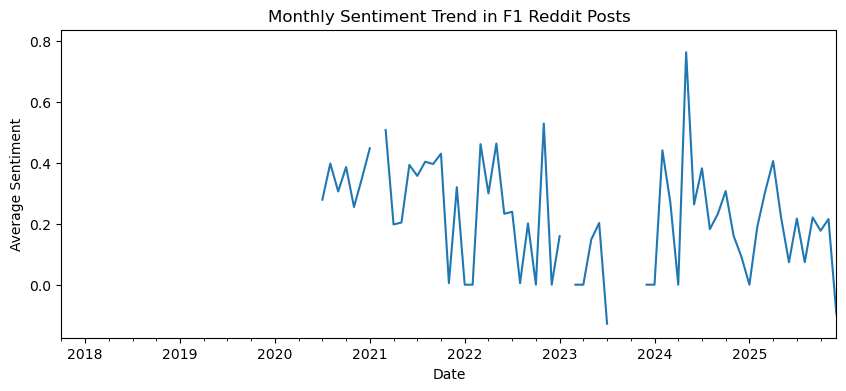

In [28]:
reddit.set_index('date')['sentiment'].resample('ME').mean().plot(figsize=(10,4))
plt.title("Monthly Sentiment Trend in F1 Reddit Posts")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.show()
